# EMOS 站点测试结果

使用 `test_data/data/xarray/spot/` 测试数据，在 **0 / 1 / 2 个 static 协变量** 三种配置下训练并订正 EMOS，对比：

1. 订正系数 α、β、γ、δ
2. 集合订正结果
3. 阈值概率
4. 分位值订正

数据约定：预报 `time`=起报，实况 `time`=有效，实况 `dtime=0`；6 个站点，3 个集合成员，5 个训练时次。


In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.emos_calibration import apply_emos, create_prob_template, train_emos
from src.grid import (
    GRID_FORECAST_DIMS,
    GRID_LAT_DIM,
    GRID_LON_DIM,
    GRID_MEMBER_DIM,
    compact_spatial_for_internal,
    normalize_grid_input,
)

DATA_DIR = ROOT / "test_data" / "data" / "xarray" / "spot"
DIM_COLS = list(GRID_FORECAST_DIMS)

TRAINER_KWARGS = dict(
    distribution="norm",
    predictor="mean",
    point_by_point=True,
    use_default_initial_guess=True,
)
THRESHOLDS = [285.0, 288.0, 292.0]
OUTPUT_PERCENTILES = [10.0, 50.0, 90.0]
RAW_PERCENTILES = [0.0, 50.0, 100.0]
INPUT_PERCENTILES = np.array(RAW_PERCENTILES, dtype=np.float32)
STATIC_CASES = [
    ("0 static", 0, "#4C72B0"),
    ("1 static (altitude)", 1, "#DD8452"),
    ("2 static (alt+slope)", 2, "#55A868"),
]

plt.rcParams.update(
    {
        "font.sans-serif": ["SimHei", "Microsoft YaHei", "DejaVu Sans"],
        "axes.unicode_minus": False,
        "figure.dpi": 100,
    }
)


def read_spot_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"])
    for col in df.columns:
        if col not in DIM_COLS:
            df[col] = df[col].astype(np.float32)
    return df


def percentile_forecast(fc):
    if isinstance(fc, pd.DataFrame):
        fc = normalize_grid_input(fc)
    axis = fc.dims.index(GRID_MEMBER_DIM)
    stacked = np.moveaxis(fc.values, axis, 0)
    data = np.percentile(stacked, INPUT_PERCENTILES, axis=0).astype(np.float32)
    other = [d for d in fc.dims if d != GRID_MEMBER_DIM]
    coords = {c: fc[c] for c in fc.coords if c != GRID_MEMBER_DIM}
    coords["percentile"] = ("percentile", INPUT_PERCENTILES, {"units": "%"})
    return xr.DataArray(
        data,
        dims=["percentile"] + other,
        coords=coords,
        attrs=fc.attrs.copy(),
        name=fc.name or "air_temperature",
    )


def sel_percentile(da: xr.DataArray, target: float) -> xr.DataArray:
    """按 percentile 坐标取值，兼容 float32 精度。"""
    coord = da["percentile"].values.astype(np.float64)
    idx = int(np.argmin(np.abs(coord - float(target))))
    if not np.isclose(coord[idx], float(target), rtol=0, atol=1e-3):
        raise KeyError(f"percentile {target} not in {coord.tolist()}")
    return da.isel(percentile=idx)


def station_value_at(da: xr.DataArray, site_idx: int) -> float:
    return float(station_table(da).iloc[site_idx][da.name or "value"])


def beta_predictor_labels(coeffs: xr.Dataset) -> list[str]:
    beta = coeffs["emos_coefficient_beta"]
    if "predictor_name" in beta.coords:
        return [str(v) for v in beta["predictor_name"].values]
    return [f"predictor_{i}" for i in range(beta.sizes["predictor_index"])]


def station_table(da: xr.DataArray) -> pd.DataFrame:
    compact = compact_spatial_for_internal(da)
    if "spot_index" in compact.dims:
        df = compact.to_dataframe(name=da.name or "value").reset_index()
        if GRID_LAT_DIM in df.columns and GRID_LON_DIM in df.columns:
            df = df.sort_values([GRID_LAT_DIM, GRID_LON_DIM])
        return df
    flat = da.stack(spot=(GRID_LAT_DIM, GRID_LON_DIM))
    df = flat.to_dataframe(name=da.name or "value").reset_index()
    return df.dropna(subset=[da.name or "value"]).sort_values([GRID_LAT_DIM, GRID_LON_DIM])


def coeff_station_values(coeffs: xr.Dataset, name: str) -> np.ndarray:
    da = coeffs[name]
    if "predictor_index" in da.dims:
        return station_table(da.isel(predictor_index=0))[da.name].to_numpy()
    return station_table(da)[da.name].to_numpy()


def run_static_case(static_count: int):
    hf = read_spot_csv(DATA_DIR / "hf.csv")
    tr = read_spot_csv(DATA_DIR / "truth.csv")
    static_all = [read_spot_csv(p) for p in sorted(DATA_DIR.glob("static_*.csv"))]
    static = static_all[:static_count] if static_count else None
    apply_fc = hf.loc[hf["time"] == hf["time"].max()].copy()
    apply_kw = dict(additional_fields=static)

    coeffs = train_emos(hf, tr, additional_fields=static, **TRAINER_KWARGS)
    ensemble = apply_emos(forecast=apply_fc, coefficients=coeffs, **apply_kw)
    prob_tpl = create_prob_template(apply_fc, THRESHOLDS, "below")
    probability = apply_emos(
        forecast=apply_fc, coefficients=coeffs, prob_template=prob_tpl, **apply_kw
    )
    pct_fc = percentile_forecast(apply_fc)
    percentiles = apply_emos(
        forecast=pct_fc,
        coefficients=coeffs,
        realizations_count=len(INPUT_PERCENTILES),
        percentiles=OUTPUT_PERCENTILES,
        **apply_kw,
    )
    return {
        "static_count": static_count,
        "apply_fc": apply_fc,
        "coeffs": coeffs,
        "ensemble": ensemble,
        "probability": probability,
        "percentiles": percentiles,
    }


## 1. 读取数据并运行三种 static 配置

In [8]:
hf = read_spot_csv(DATA_DIR / "hf.csv")
tr = read_spot_csv(DATA_DIR / "truth.csv")
static_files = sorted(DATA_DIR.glob("static_*.csv"))
print("historic forecast:", len(hf), "rows")
print("truth:", len(tr), "rows")
print("static files:", [p.name for p in static_files])
print("stations:", hf[["lat", "lon"]].drop_duplicates().shape[0])

results = {n: run_static_case(n) for _, n, _ in STATIC_CASES}
print("完成 0/1/2 static 训练与订正")


historic forecast: 90 rows
truth: 30 rows
static files: ['static_altitude.csv', 'static_slope.csv']
stations: 6


D:\chengxv_time\202607\emos_xarray\src\emos.py:220: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  hf_out = xr.concat(hf_slices, dim=TIME_DIM)
D:\chengxv_time\202607\emos_xarray\src\emos.py:593: UserWarning: Forecast values exist that fall outside the expected extrema values [-373.15 -213.15]. Exceeded values will be used as new bounds.
  warnings.warn(msg + " Exceeded values will be used as new bounds.")
D:\chengxv_time\202607\emos_xarray\src\xr_utils.py:740: UserWarning: Module numba unavailable. ResamplePercentiles will be slower.
  warnings.warn("Module numba unavailable. ResamplePercentiles will be slower.")
D:\chengxv_time\202607\emos_xarray\sr

完成 0/1/2 static 训练与订正


D:\chengxv_time\202607\emos_xarray\src\emos.py:593: UserWarning: Forecast values exist that fall outside the expected extrema values [-373.15 -213.15]. Exceeded values will be used as new bounds.
  warnings.warn(msg + " Exceeded values will be used as new bounds.")
D:\chengxv_time\202607\emos_xarray\src\xr_utils.py:740: UserWarning: Module numba unavailable. ResamplePercentiles will be slower.
  warnings.warn("Module numba unavailable. ResamplePercentiles will be slower.")


## 2. 订正系数对比

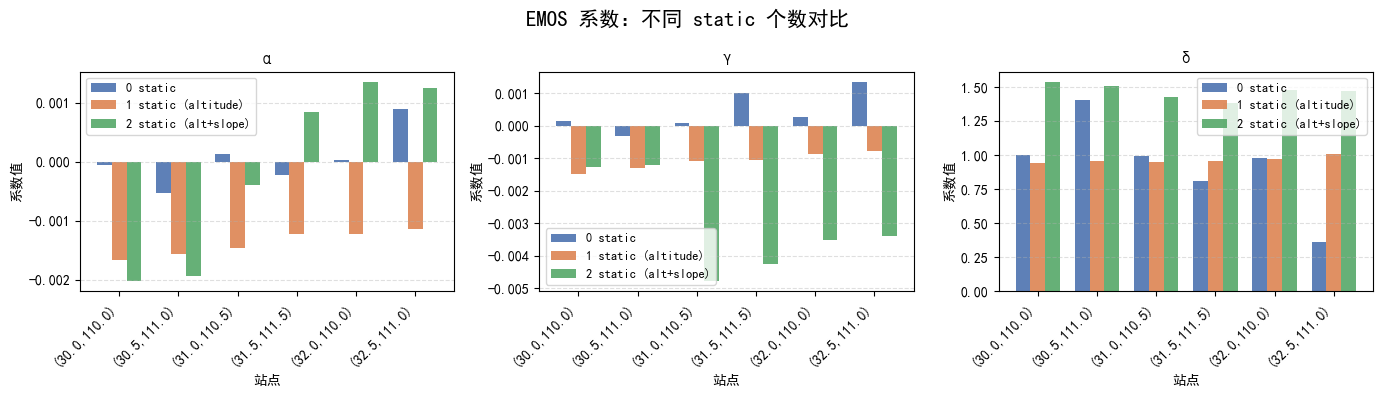

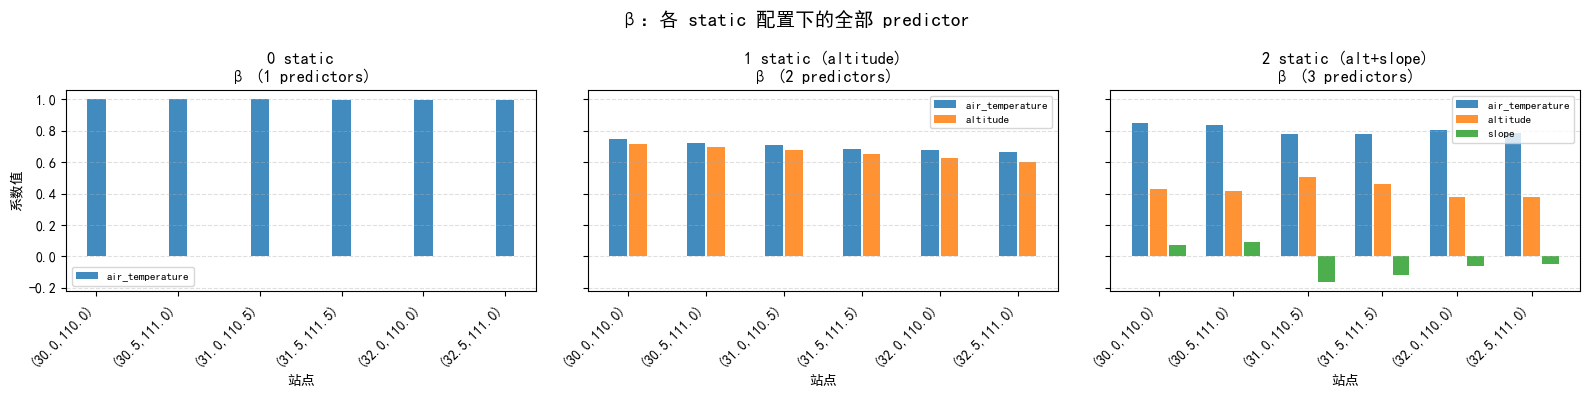

In [9]:
stations = (
    results[0]["apply_fc"][["lat", "lon"]]
    .drop_duplicates()
    .sort_values(["lat", "lon"])
    .reset_index(drop=True)
)
station_labels = [f"({r.lat:.1f},{r.lon:.1f})" for r in stations.itertuples()]
x = np.arange(len(station_labels))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
param_names = [
    "emos_coefficient_alpha",
    "emos_coefficient_gamma",
    "emos_coefficient_delta",
]
titles = ["α", "γ", "δ"]

for ax, pname, title in zip(axes, param_names, titles):
    for offset, (label, n_static, color) in enumerate(STATIC_CASES):
        vals = coeff_station_values(results[n_static]["coeffs"], pname)
        ax.bar(x + (offset - 1) * width, vals, width=width, label=label, color=color, alpha=0.9)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("站点")
    ax.set_ylabel("系数值")
    ax.set_xticks(x)
    ax.set_xticklabels(station_labels, rotation=45, ha="right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.legend(fontsize=9)

fig.suptitle("EMOS 系数：不同 static 个数对比", fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

fig_beta, beta_axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (label, n_static, color) in zip(beta_axes, STATIC_CASES):
    beta = results[n_static]["coeffs"]["emos_coefficient_beta"]
    pred_labels = beta_predictor_labels(results[n_static]["coeffs"])
    n_pred = len(pred_labels)
    sub_w = min(0.8 / max(n_pred, 1), width)
    for p_idx, pred in enumerate(pred_labels):
        vals = station_table(beta.isel(predictor_index=p_idx))[beta.name].to_numpy()
        ax.bar(
            x + (p_idx - (n_pred - 1) / 2) * sub_w,
            vals,
            width=sub_w * 0.9,
            label=pred,
            alpha=0.85,
        )
    ax.set_title(f"{label}\nβ ({n_pred} predictors)", fontweight="bold")
    ax.set_xlabel("站点")
    ax.set_xticks(x)
    ax.set_xticklabels(station_labels, rotation=45, ha="right")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.legend(fontsize=8)
beta_axes[0].set_ylabel("系数值")
fig_beta.suptitle("β：各 static 配置下的全部 predictor", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. 集合订正：各站集合均值

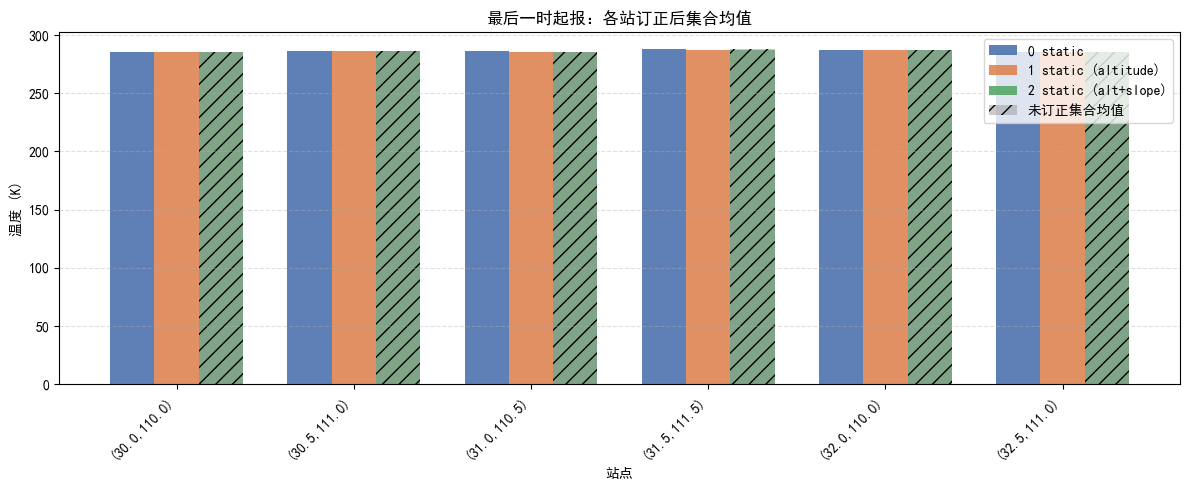

In [10]:
def ensemble_mean_by_station(ens_ds: xr.Dataset) -> np.ndarray:
    da = ens_ds["air_temperature"]
    return station_table(da.mean(GRID_MEMBER_DIM))[da.name].to_numpy()

raw_fc = normalize_grid_input(results[0]["apply_fc"])
raw_mean = station_table(raw_fc.mean(GRID_MEMBER_DIM))[raw_fc.name].to_numpy()

fig, ax = plt.subplots(figsize=(12, 5))
for offset, (label, n_static, color) in enumerate(STATIC_CASES):
    vals = ensemble_mean_by_station(results[n_static]["ensemble"])
    ax.bar(x + (offset - 1) * width, vals, width=width, label=label, color=color, alpha=0.9)
ax.bar(x + width, raw_mean, width=width, label="未订正集合均值", color="#999999", alpha=0.5, hatch="//")
ax.set_title("最后一时起报：各站订正后集合均值", fontweight="bold")
ax.set_xlabel("站点")
ax.set_ylabel("温度 (K)")
ax.set_xticks(x)
ax.set_xticklabels(station_labels, rotation=45, ha="right")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()


## 4. 阈值概率对比

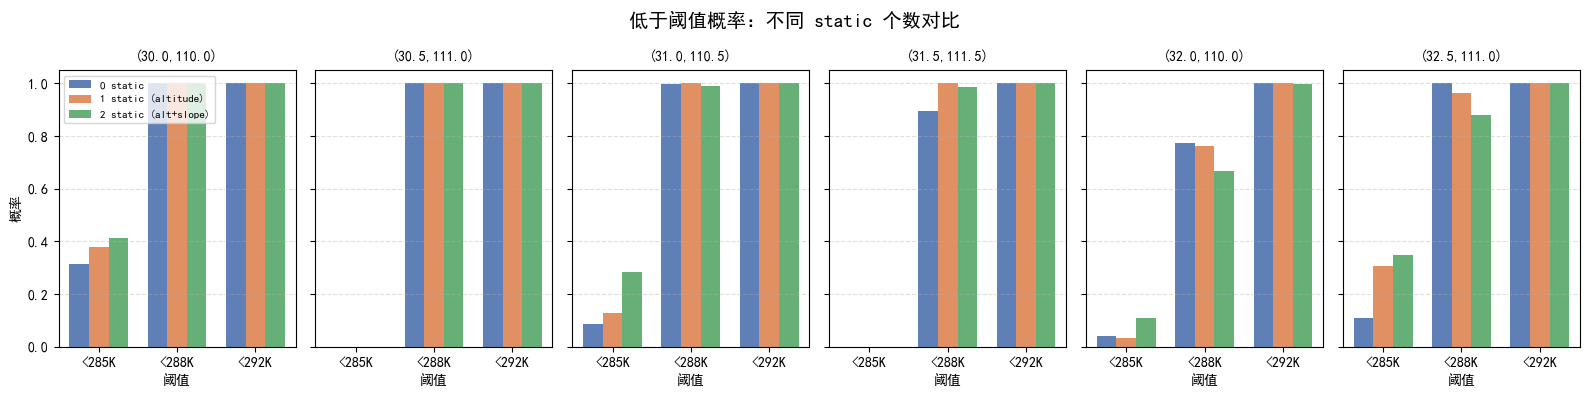

In [11]:
prob_var = "probability_of_air_temperature_below_threshold"
fig, axes = plt.subplots(1, len(station_labels), figsize=(16, 4), sharey=True)
if len(station_labels) == 1:
    axes = [axes]

for s_idx, ax in enumerate(axes):
    for offset, (label, n_static, color) in enumerate(STATIC_CASES):
        prob = results[n_static]["probability"][prob_var]
        st_all = [
            station_table(prob.isel(threshold=t_idx)).iloc[s_idx][prob.name]
            for t_idx in range(len(THRESHOLDS))
        ]
        ax.bar(
            np.arange(len(THRESHOLDS)) + (offset - 1) * width,
            st_all,
            width=width,
            label=label,
            color=color,
            alpha=0.9,
        )
    ax.set_title(station_labels[s_idx], fontsize=10)
    ax.set_xticks(np.arange(len(THRESHOLDS)))
    ax.set_xticklabels([f"<{t:.0f}K" for t in THRESHOLDS])
    ax.set_xlabel("阈值")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    if s_idx == 0:
        ax.set_ylabel("概率")
        ax.legend(fontsize=8)

fig.suptitle("低于阈值概率：不同 static 个数对比", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. 分位值订正对比

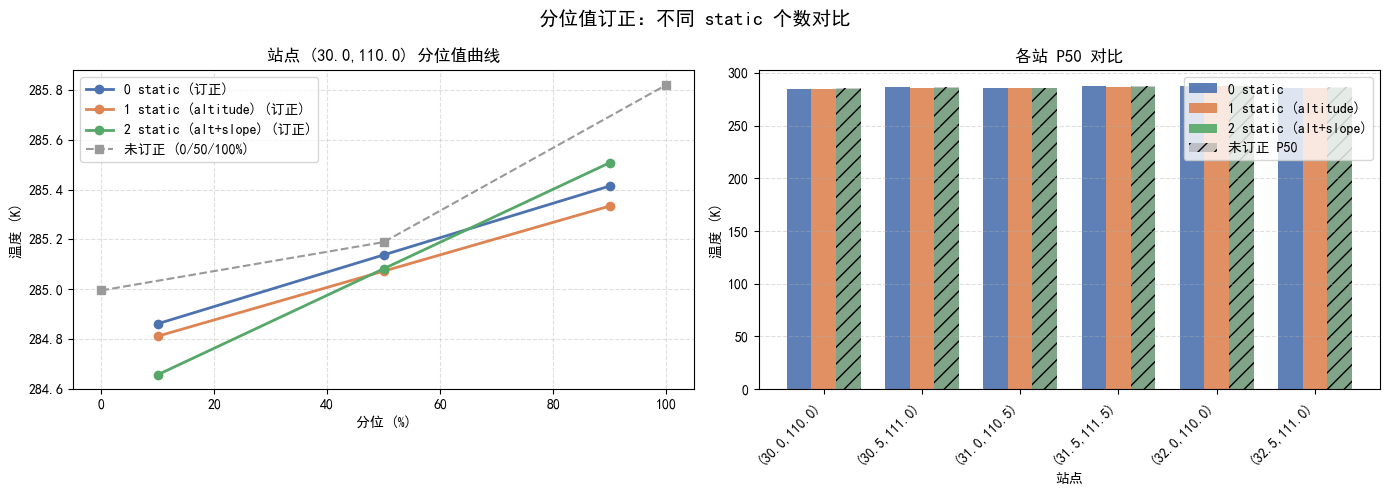

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

site_idx = 0
raw_pct = percentile_forecast(results[0]["apply_fc"])

for label, n_static, color in STATIC_CASES:
    pct = results[n_static]["percentiles"]["air_temperature"]
    vals = [station_value_at(sel_percentile(pct, p), site_idx) for p in OUTPUT_PERCENTILES]
    axes[0].plot(OUTPUT_PERCENTILES, vals, marker="o", label=f"{label} (订正)", color=color, linewidth=2)

raw_vals = [station_value_at(sel_percentile(raw_pct, p), site_idx) for p in RAW_PERCENTILES]
axes[0].plot(
    RAW_PERCENTILES,
    raw_vals,
    marker="s",
    label="未订正 (0/50/100%)",
    color="#999999",
    linestyle="--",
)
axes[0].set_title(f"站点 {station_labels[site_idx]} 分位值曲线", fontweight="bold")
axes[0].set_xlabel("分位 (%)")
axes[0].set_ylabel("温度 (K)")
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend()

for offset, (label, n_static, color) in enumerate(STATIC_CASES):
    pct = results[n_static]["percentiles"]["air_temperature"]
    vals = station_table(sel_percentile(pct, 50.0))[pct.name].to_numpy()
    axes[1].bar(x + (offset - 1) * width, vals, width=width, label=label, color=color, alpha=0.9)
raw_p50 = station_table(sel_percentile(raw_pct, 50.0))[raw_pct.name].to_numpy()
axes[1].bar(x + width, raw_p50, width=width, label="未订正 P50", color="#999999", alpha=0.5, hatch="//")
axes[1].set_title("各站 P50 对比", fontweight="bold")
axes[1].set_xlabel("站点")
axes[1].set_ylabel("温度 (K)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(station_labels, rotation=45, ha="right")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.4)
axes[1].legend()

fig.suptitle("分位值订正：不同 static 个数对比", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
